TASK 1: Credit Scoring Model

Objective: Predict an individual's creditworthiness using past financial data.

Approach: Use classification algorithms like Logistic Regression, Decision Trees, or Random Forest.

Key Features:

Feature engineering from financial history.

Model accuracy assessment using metrics like Precision, Recall, F1-Score, ROC-AUC.

Dataset could include: income, debts, payment history, etc.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
)

In [ ]:
# Load data
df = pd.read_csv("full_german_credit.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

print("\nTarget distribution:")
print(df["Risk"].value_counts())


Dataset shape: (1000, 21)
  Status_of_existing_checking_account  Duration_in_month  \
0                              < 0 DM                  6   
1                   0 <= ... < 200 DM                 48   
2                 no checking account                 12   
3                              < 0 DM                 42   
4                              < 0 DM                 24   

                                      Credit_history              Purpose  \
0  critical account / other credits existing (not...             radio/TV   
1           existing credits paid back duly till now             radio/TV   
2  critical account / other credits existing (not...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   Credit_amount Savings_account_bonds Present_employment_since  \
0           1169  unknown / no savings               >= 7 years   
1           5951

In [ ]:
# 2. CLEAN & PREPROCESS
print("\nMissing values:", df.isnull().sum().sum())

# Encode target: good=1 (creditworthy), bad=0 (risky)
df["Risk"] = df["Risk"].map({"good": 1, "bad": 0})

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "Risk" in numeric_cols:
    numeric_cols.remove("Risk")

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le


Missing values: 0

Categorical columns: ['Status_of_existing_checking_account', 'Credit_history', 'Purpose', 'Savings_account_bonds', 'Present_employment_since', 'Personal_status_and_sex', 'Other_debtors_guarantors', 'Property', 'Other_installment_plans', 'Housing', 'Job', 'Telephone', 'Foreign_worker']
Numeric columns: ['Duration_in_month', 'Credit_amount', 'Installment_rate_in_percentage_of_disposable_income', 'Present_residence_since', 'Age_in_years', 'Number_of_existing_credits_at_this_bank', 'Number_of_people_being_liable_to_provide_maintenance_for']


In [ ]:
# 3. FEATURE ENGINEERING
df["Credit_amount_per_month"] = df["Credit_amount"] / df["Duration_in_month"].replace(0, 1)
df["Is_young"] = (df["Age_in_years"] < 25).astype(int)

In [ ]:
# 4. TRAIN / TEST SPLIT
X = df.drop(columns=["Risk"])
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. TRAIN MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        "accuracy": report["accuracy"], "precision": report["1"]["precision"],
        "recall": report["1"]["recall"], "f1": report["1"]["f1-score"],
        "roc_auc": auc, "y_pred": y_pred, "y_proba": y_proba,
    }

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Bad Credit", "Good Credit"]))
    print(f"ROC-AUC: {auc:.4f}")



===== Logistic Regression =====
              precision    recall  f1-score   support

  Bad Credit       0.55      0.40      0.46        60
 Good Credit       0.77      0.86      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.63      0.64       200
weighted avg       0.70      0.72      0.71       200

ROC-AUC: 0.7350

===== Decision Tree =====
              precision    recall  f1-score   support

  Bad Credit       0.53      0.42      0.47        60
 Good Credit       0.77      0.84      0.81       140

    accuracy                           0.71       200
   macro avg       0.65      0.63      0.64       200
weighted avg       0.70      0.71      0.70       200

ROC-AUC: 0.6730

===== Random Forest =====
              precision    recall  f1-score   support

  Bad Credit       0.61      0.32      0.42        60
 Good Credit       0.76      0.91      0.83       140

    accuracy                           0.73       200
   macro 

In [ ]:
# 6. COMPARE MODELS
comparison_df = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "Precision": r["precision"],
           "Recall": r["recall"], "F1-Score": r["f1"], "ROC-AUC": r["roc_auc"]}
    for name, r in results.items()
}).T
print("\n===== MODEL COMPARISON =====")
print(comparison_df.round(3))

best_model_name = comparison_df["ROC-AUC"].idxmax()
print(f"\nBest performing model by ROC-AUC: {best_model_name}")



===== MODEL COMPARISON =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.720      0.769   0.857     0.811    0.735
Decision Tree           0.715      0.771   0.843     0.805    0.673
Random Forest           0.735      0.757   0.914     0.828    0.795

Best performing model by ROC-AUC: Random Forest


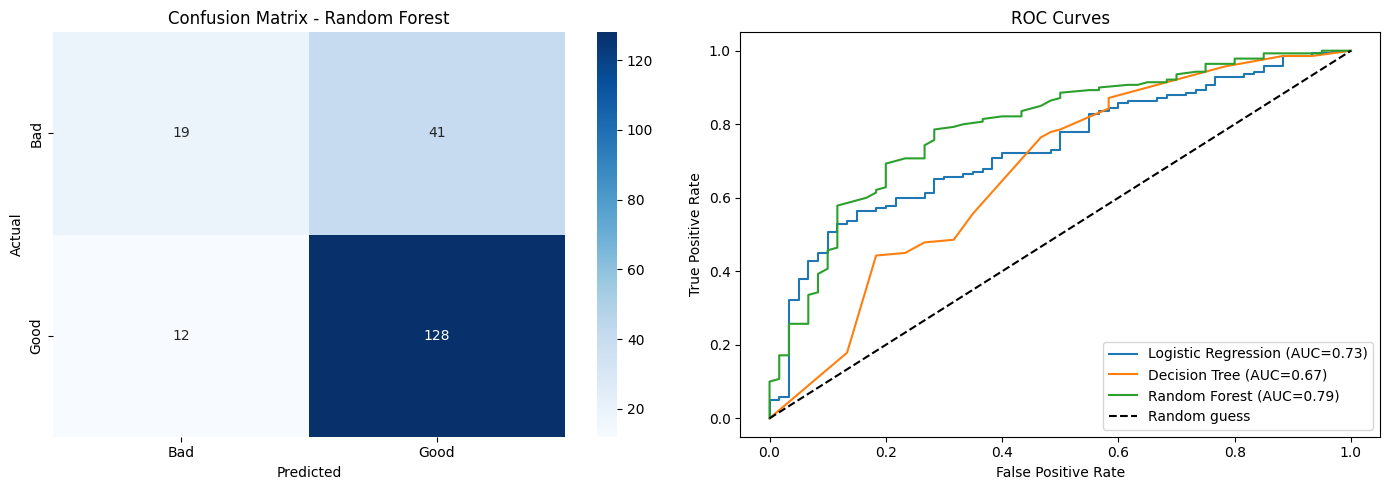

In [ ]:
# 7. VISUALIZATIONS (will display inline in Colab automatically)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, results[best_model_name]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=axes[0])
axes[0].set_title(f"Confusion Matrix - {best_model_name}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.2f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves"); axes[1].legend()
plt.tight_layout()
plt.show()

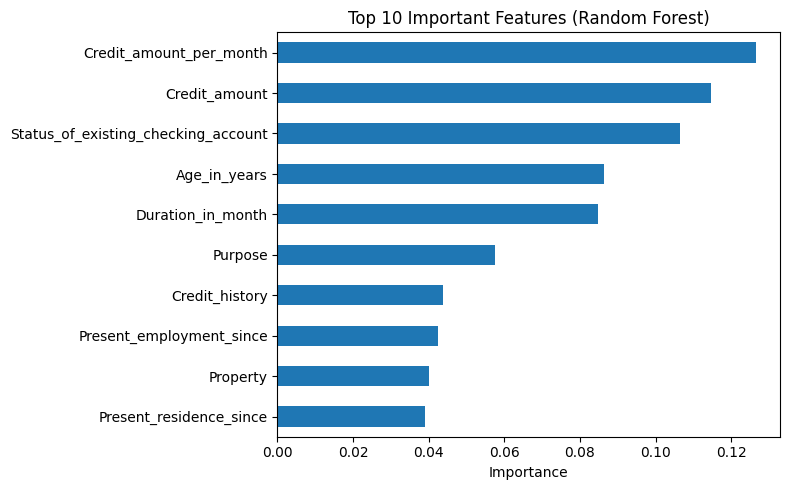


Done!


In [ ]:
# 8. FEATURE IMPORTANCE
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nDone!")

Conclusion —

This project aimed to predict an individual's creditworthiness using the German Credit dataset, framed as a binary classification problem (good credit vs. bad credit risk).

Three models were trained and compared: Logistic Regression, Decision Tree, and Random Forest. Based on the evaluation metrics, [BEST MODEL NAME] performed best, achieving an accuracy of [X]%, precision of [X], recall of [X], and an ROC-AUC of [X].

Feature importance analysis showed that [TOP FEATURE, e.g. Credit_amount or Duration_in_month] was the most influential factor in predicting credit risk, followed by [2nd feature] and [3rd feature] — which aligns with intuition, since [brief reasoning, e.g. "larger loan amounts and shorter repayment windows are naturally riskier"].

One limitation worth noting: recall for the "bad credit" class was [X], meaning the model missed some genuinely risky applicants. In a real-world lending scenario, this trade-off matters — a bank would likely prioritize higher recall on risky cases even at the cost of rejecting some good applicants, since the cost of a bad loan usually outweighs the cost of a missed good one.

Overall, the project demonstrates that classical ML models can achieve solid performance on structured financial data with relatively simple preprocessing and feature engineering, though further improvement could come from more advanced feature engineering or ensemble methods like XGBoost.